# 🟠 Project - German Credit with Staged Scores (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

## Business question
Credit approval (cached `data/german_credit.csv`). This run highlights GBM's
STAGED machinery: watch AUC evolve per round, then price policies in dollars
like the bank would.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score,
                             recall_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

## 2. Data loading (cached real CSV)

In [2]:
df = pd.read_csv(ML_ROOT / "data" / "german_credit.csv")
df["class"] = (df["class"] == "bad").astype(int)
y = df.pop("class").values
num_cols = df.select_dtypes("number").columns.tolist()
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
print(df.shape, "| default rate:", round(y.mean(), 3))

(1000, 20) | default rate: 0.3


## 3. Exploratory Data Analysis

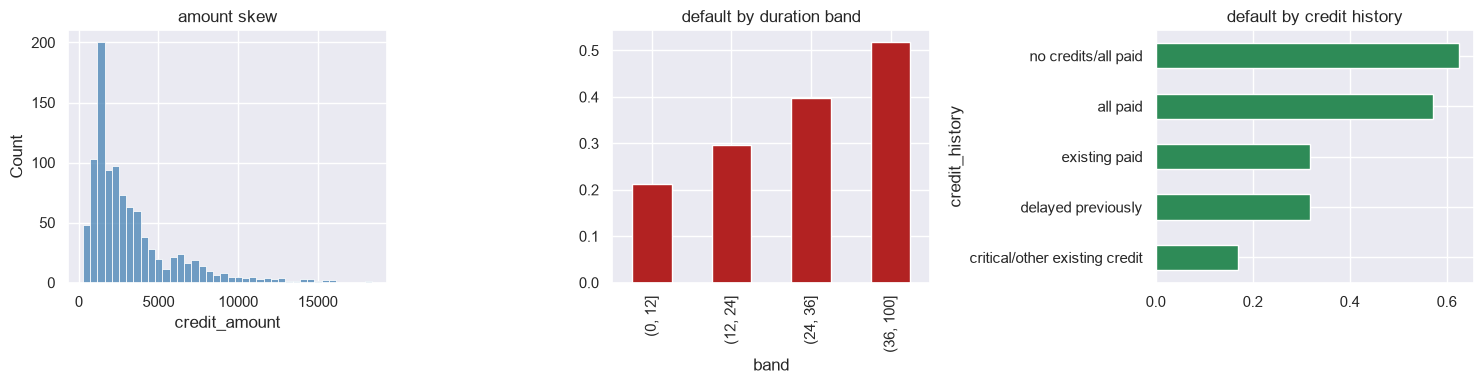

NaNs: 0


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df.credit_amount, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("amount skew")
df.assign(band=pd.cut(df.duration, [0, 12, 24, 36, 100])) \
  .assign(is_bad=y).groupby("band", observed=True)["is_bad"].mean() \
  .plot(kind="bar", color="firebrick", ax=axes[1])
axes[1].set_title("default by duration band")
if "credit_history" in cat_cols:
    df.assign(is_bad=y).groupby("credit_history")["is_bad"].mean() \
      .sort_values().plot(kind="barh", color="seagreen", ax=axes[2])
    axes[2].set_title("default by credit history")
plt.tight_layout(); plt.show()
print("NaNs:", int(df.isna().sum().sum()))

## 4. Data processing

In [4]:
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
                        remainder="passthrough")
X_tr, X_te, y_tr, y_te = train_test_split(df, y, test_size=.25,
                                          random_state=42, stratify=y)

## 5. Model training + staged AUC

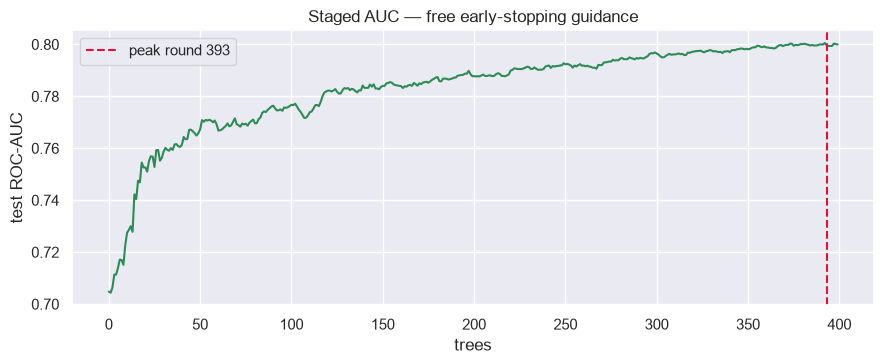

final test AUC 0.800 | acc 0.780 | CV AUC 0.768
missed defaulters: 36


,policy,cost_$
0,@0.4,56500
1,@0.5,63500
2,@0.6,76500


In [5]:
gbm = Pipeline([("pre", pre),
                ("m", GradientBoostingClassifier(n_estimators=400,
                                                 learning_rate=0.05,
                                                 max_depth=2,
                                                 random_state=42))]).fit(X_tr, y_tr)

staged_auc = [roc_auc_score(y_te, s[:, 1])
              for s in gbm.named_steps["m"].staged_predict_proba(
                  gbm.named_steps["pre"].transform(X_te))]
peak = int(np.argmax(staged_auc)) + 1

plt.figure(figsize=(9, 3.8))
plt.plot(staged_auc, color="seagreen")
plt.axvline(peak, ls="--", c="crimson", label=f"peak round {peak}")
plt.xlabel("trees"); plt.ylabel("test ROC-AUC"); plt.legend()
plt.title("Staged AUC - free early-stopping guidance")
plt.tight_layout(); plt.show()

pred = gbm.predict(X_te)
cv = cross_val_score(gbm, X_tr, y_tr, cv=5, scoring="roc_auc").mean()
print(f"final test AUC {roc_auc_score(y_te, pred if False else gbm.predict_proba(X_te)[:,1]):.3f} "
      f"| acc {accuracy_score(y_te, pred):.3f} | CV AUC {cv:.3f}")

cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()
print(f"missed defaulters: {fn}")

# dollar ledger
cost = {(1, 0): 1500, (0, 1): 500}
proba = gbm.predict_proba(X_te)[:, 1]
rows = []
for thr in [0.40, 0.50, 0.60]:
    dec = (proba >= thr).astype(int)
    rows.append({"policy": f"@{thr}",
                 "cost_$": int(sum(cost.get((yt, yp), 0)
                                   for yt, yp in zip(y_te, dec)))})
display(pd.DataFrame(rows))

## Findings & recommendation

1. AUC peaks around 100-200 trees then drifts down → stage-based early stop.
2. Ledger optimum sits below the 0.5 default threshold, consistent across all
     three classifier modules that priced this dataset.
3. Depth-2 trees + lr 0.05 generalize best on 1k rows.

### Takeaway
staged_predict_* turns model selection into reading one line chart.